In [1]:
#训练数据提取
import warnings
warnings.simplefilter("ignore")
from prepare import train_properties_and_names

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

train_properties, feature_names = train_properties_and_names()
dataset_path = 'data_filled_400.csv'

# read dataset
datas = pd.read_csv(dataset_path)
data = datas.drop(['element1','element2','NO(%)'],axis=1)
target = datas['NO(%)']

FileNotFoundError: [Errno 2] No such file or directory: 'data_filled_400.csv'

In [2]:
import numpy as np
from sklearn.utils import resample
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def bootstrap_predict_ci(
    model, X_train, y_train, X_val, y_val=None,
    n_boot=1000, alpha=0.05, random_state=None,
    return_dict=True
):
    """
    Bootstrap 预测区间 + 性能指标分布（MAE / RMSE / R² / MRE）
    """

    rng = np.random.RandomState(random_state)
    preds = []

    mae_list = []
    rmse_list = []
    r2_list = []
    mre_list = []   # ✅ 新增

    y_val_arr = None
    if y_val is not None:
        y_val_arr = np.asarray(y_val).ravel()

        # ✅ 自适应 eps（避免除0 & 小值爆炸）
        eps = 1e-6 * np.mean(np.abs(y_val_arr))

    for _ in range(n_boot):
        # 1) bootstrap 采样训练集
        X_bs, y_bs = resample(
            X_train, y_train,
            replace=True,
            random_state=rng.randint(0, 1_000_000)
        )

        # 2) 克隆模型
        model_bs = clone(model)

        # 3) 训练
        model_bs.fit(X_bs, y_bs)

        # 4) 预测
        y_pred = np.asarray(model_bs.predict(X_val)).ravel()
        preds.append(y_pred)

        # 5) 指标计算
        if y_val_arr is not None:
            mae_list.append(mean_absolute_error(y_val_arr, y_pred))
            rmse_list.append(np.sqrt(mean_squared_error(y_val_arr, y_pred)))
            r2_list.append(r2_score(y_val_arr, y_pred))

            # ===== ✅ MRE =====
            rel_error = np.abs((y_val_arr - y_pred) / (y_val_arr + eps))
            mre_list.append(np.mean(rel_error))

    preds = np.asarray(preds)

    # ===== 预测CI =====
    mean_pred = preds.mean(axis=0)
    lower = np.percentile(preds, 100 * (alpha / 2), axis=0)
    upper = np.percentile(preds, 100 * (1 - alpha / 2), axis=0)
    ci_width = upper - lower

    print("平均CI宽度:", np.mean(ci_width))

    if not return_dict:
        return mean_pred, lower, upper, preds

    results = {
        "mean_pred": mean_pred,
        "lower": lower,
        "upper": upper,
        "preds": preds,
        "ci_width": ci_width
    }

    # ===== 指标统计 =====
    if y_val_arr is not None:
        mae_arr = np.asarray(mae_list)
        rmse_arr = np.asarray(rmse_list)
        r2_arr = np.asarray(r2_list)
        mre_arr = np.asarray(mre_list)  # ✅ 新增

        def _summary(arr):
            return {
                "mean": float(np.mean(arr)),
                "std": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
                "ci_low": float(np.percentile(arr, 100 * (alpha / 2))),
                "ci_high": float(np.percentile(arr, 100 * (1 - alpha / 2)))
            }

        results.update({
            "mae": mae_arr,
            "rmse": rmse_arr,
            "r2": r2_arr,
            "mre": mre_arr,  # ✅ 新增
            "summary": {
                "mae": _summary(mae_arr),
                "rmse": _summary(rmse_arr),
                "r2": _summary(r2_arr),
                "mre": _summary(mre_arr)  # ✅ 新增
            }
        })

        # ===== 打印 =====
        print(f"MAE 均值: {results['summary']['mae']['mean']:.4f} ± {results['summary']['mae']['std']:.4f}")
        print(f"RMSE 均值: {results['summary']['rmse']['mean']:.4f} ± {results['summary']['rmse']['std']:.4f}")
        print(f"R² 均值: {results['summary']['r2']['mean']:.4f} ± {results['summary']['r2']['std']:.4f}")
        print(f"MRE 均值: {results['summary']['mre']['mean']:.4f} ± {results['summary']['mre']['std']:.4f}")

        print(f"MAE 95% CI: ({results['summary']['mae']['ci_low']:.4f}, {results['summary']['mae']['ci_high']:.4f})")
        print(f"RMSE 95% CI: ({results['summary']['rmse']['ci_low']:.4f}, {results['summary']['rmse']['ci_high']:.4f})")
        print(f"R² 95% CI: ({results['summary']['r2']['ci_low']:.4f}, {results['summary']['r2']['ci_high']:.4f})")
        print(f"MRE 95% CI: ({results['summary']['mre']['ci_low']:.4f}, {results['summary']['mre']['ci_high']:.4f})")

    return results

In [3]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=352)

In [4]:
xgb0 = XGBRegressor(random_state=0)
xgb1 = XGBRegressor(colsample_bytree=1, eta=0.05, eval_metric='rmse',
                  max_depth=3, n_estimators=400, seed=2, subsample=0.5)
gb0 = GradientBoostingRegressor()
gb1 = GradientBoostingRegressor(learning_rate=0.05, max_depth=7, min_samples_leaf=1, min_samples_split=3,n_estimators=175, subsample=0.7, random_state=14)
cb0 = CatBoostRegressor(verbose=False)
cb1 = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,random_state=0,verbose=False)

In [6]:
results = bootstrap_predict_ci(
    model=cb0,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=100,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 15.489711741250177
MAE 均值: 6.8282 ± 0.7757
RMSE 均值: 8.9068 ± 0.9587
R² 均值: 0.7716 ± 0.0505
MRE 均值: 0.2154 ± 0.0268
MAE 95% CI: (5.5065, 8.6213)
RMSE 95% CI: (7.3178, 11.0116)
R² 95% CI: (0.6548, 0.8475)
MRE 95% CI: (0.1745, 0.2694)


In [14]:
results = bootstrap_predict_ci(
    model=cb1,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 17.85983167037871
MAE 均值: 6.9377 ± 0.7441
RMSE 均值: 9.0179 ± 0.9646
R² 均值: 0.7658 ± 0.0512
MRE 均值: 0.2173 ± 0.0257
MAE 95% CI: (5.7232, 8.5985)
RMSE 95% CI: (7.3627, 11.0957)
R² 95% CI: (0.6495, 0.8457)
MRE 95% CI: (0.1733, 0.2731)


In [9]:
results = bootstrap_predict_ci(
    model=xgb0,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 22.871279
MAE 均值: 7.6312 ± 0.9381
RMSE 均值: 10.0730 ± 1.3473
R² 均值: 0.7060 ± 0.0794
MRE 均值: 0.2395 ± 0.0335
MAE 95% CI: (6.0786, 9.5938)
RMSE 95% CI: (7.9157, 12.8252)
R² 95% CI: (0.5317, 0.8216)
MRE 95% CI: (0.1845, 0.3067)


In [15]:
results = bootstrap_predict_ci(
    model=xgb1,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 18.59268
MAE 均值: 7.0331 ± 0.7546
RMSE 均值: 9.1852 ± 0.9860
R² 均值: 0.7570 ± 0.0528
MRE 均值: 0.2210 ± 0.0262
MAE 95% CI: (5.6706, 8.6200)
RMSE 95% CI: (7.4964, 11.2751)
R² 95% CI: (0.6381, 0.8400)
MRE 95% CI: (0.1746, 0.2772)


In [11]:
results = bootstrap_predict_ci(
    model=gb0,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 19.54411720015896
MAE 均值: 7.7449 ± 0.9546
RMSE 均值: 9.8999 ± 1.2733
R² 均值: 0.7164 ± 0.0753
MRE 均值: 0.2438 ± 0.0332
MAE 95% CI: (6.3954, 9.8521)
RMSE 95% CI: (8.1020, 12.6249)
R² 95% CI: (0.5462, 0.8131)
MRE 95% CI: (0.1943, 0.3210)


In [16]:
results = bootstrap_predict_ci(
    model=gb1,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 19.79279401182838
MAE 均值: 7.3344 ± 0.8472
RMSE 均值: 9.5485 ± 1.1367
R² 均值: 0.7368 ± 0.0636
MRE 均值: 0.2261 ± 0.0301
MAE 95% CI: (5.8146, 9.1366)
RMSE 95% CI: (7.5792, 11.9300)
R² 95% CI: (0.5948, 0.8365)
MRE 95% CI: (0.1763, 0.2894)


In [ ]:
def draw_scatter(
        train_true, train_pred,
        test_true, mean_pred,   # ⭐ 用bootstrap均值
        title,
        test_lower=None, test_upper=None,
        mode='errorbar',  # 'errorbar' or 'ci'
        save=False):

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.rcParams['font.family'] = 'Times New Roman'
    plt.figure(figsize=(7, 7), dpi=600)

    # ===== 散点 =====
    plt.scatter(train_true, train_pred,
                color="dodgerblue", alpha=0.6, s=40, label="Train")

    plt.scatter(test_true, mean_pred,
                color="orange", alpha=0.8, s=45, edgecolor='k',
                label="Test")

    # ===== 排序（用于CI）=====
    sorted_idx = np.argsort(test_true)
    x = test_true[sorted_idx]
    y = mean_pred[sorted_idx]

    if test_lower is not None and test_upper is not None:
        lower = test_lower[sorted_idx]
        upper = test_upper[sorted_idx]

        # ===== 模式1：误差棒 =====
        if mode == 'errorbar':
            yerr_lower = np.maximum(y - lower, 0)
            yerr_upper = np.maximum(upper - y, 0)

            plt.errorbar(
                x, y,
                yerr=[yerr_lower, yerr_upper],
                fmt='none',
                ecolor='gray',
                alpha=0.5,
                capsize=2,
                linewidth=1,
                label='95% CI'
            )

        # ===== 模式2：置信区间阴影（推荐）=====
        elif mode == 'ci':
            plt.fill_between(
                x, lower, upper,
                color='lightgray',
                alpha=0.5,
                label='95% CI'
            )

    # ===== 理想线 =====
    min_val = min(test_true.min(), mean_pred.min())
    max_val = max(test_true.max(), mean_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Ideal Fit')

    # ===== 坐标 =====
    plt.xlabel("Actual", fontsize=16, fontweight='bold')
    plt.ylabel("Predicted", fontsize=16, fontweight='bold')

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)

    # ===== 图例（右下角）=====
    plt.legend(loc='lower right', fontsize=12, frameon=True)

    # ===== 坐标轴美化 =====
    ax = plt.gca()
    ax.tick_params(length=6, width=1.5, labelsize=12)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.grid(alpha=0.3, linestyle='--')

    # ===== 统计信息（自动位置）=====
    from sklearn.metrics import r2_score, mean_squared_error

    r2 = r2_score(test_true, mean_pred)
    rmse = np.sqrt(mean_squared_error(test_true, mean_pred))

    plt.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
    )

    plt.title(title, fontsize=16, fontweight='bold')

    plt.tight_layout()

    if save:
        plt.savefig(f"{title}.jpg", dpi=600)

    plt.show()

In [ ]:
a = bootstrap_predict_ci(
    model=xg,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=10,
    alpha=0.05,
    random_state=42
)



In [ ]:
a

In [29]:

from prepare import process_regressor,model_performance_metrics
train_pred, test_pred = process_regressor(xg, x_train, x_test, y_train, y_test)
model_performance_metrics('XGB Train', y_train, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)


cv train R2: 0.559 (+/- 0.069) 

XGB Train mse: 0.00056 | rmse: 0.02366 | mae: 0.01848 | mape: 4.72320 | smape: 4.62796 | r2: 0.98172

XGB Test mse: 0.00400 | rmse: 0.06324 | mae: 0.04884 | mape: 15.23135 | smape: 13.32350 | r2: 0.88614



0.8861381092142073

KeyError: '[29, 43, 18, 45, 27, 35, 20, 22, 44, 4, 12, 1, 19, 3, 9, 32, 10, 5, 7, 33, 21, 41, 39, 47, 6, 26, 13, 30, 42, 34, 48, 15, 16, 24, 38, 0, 31, 37, 40, 2] not in index'

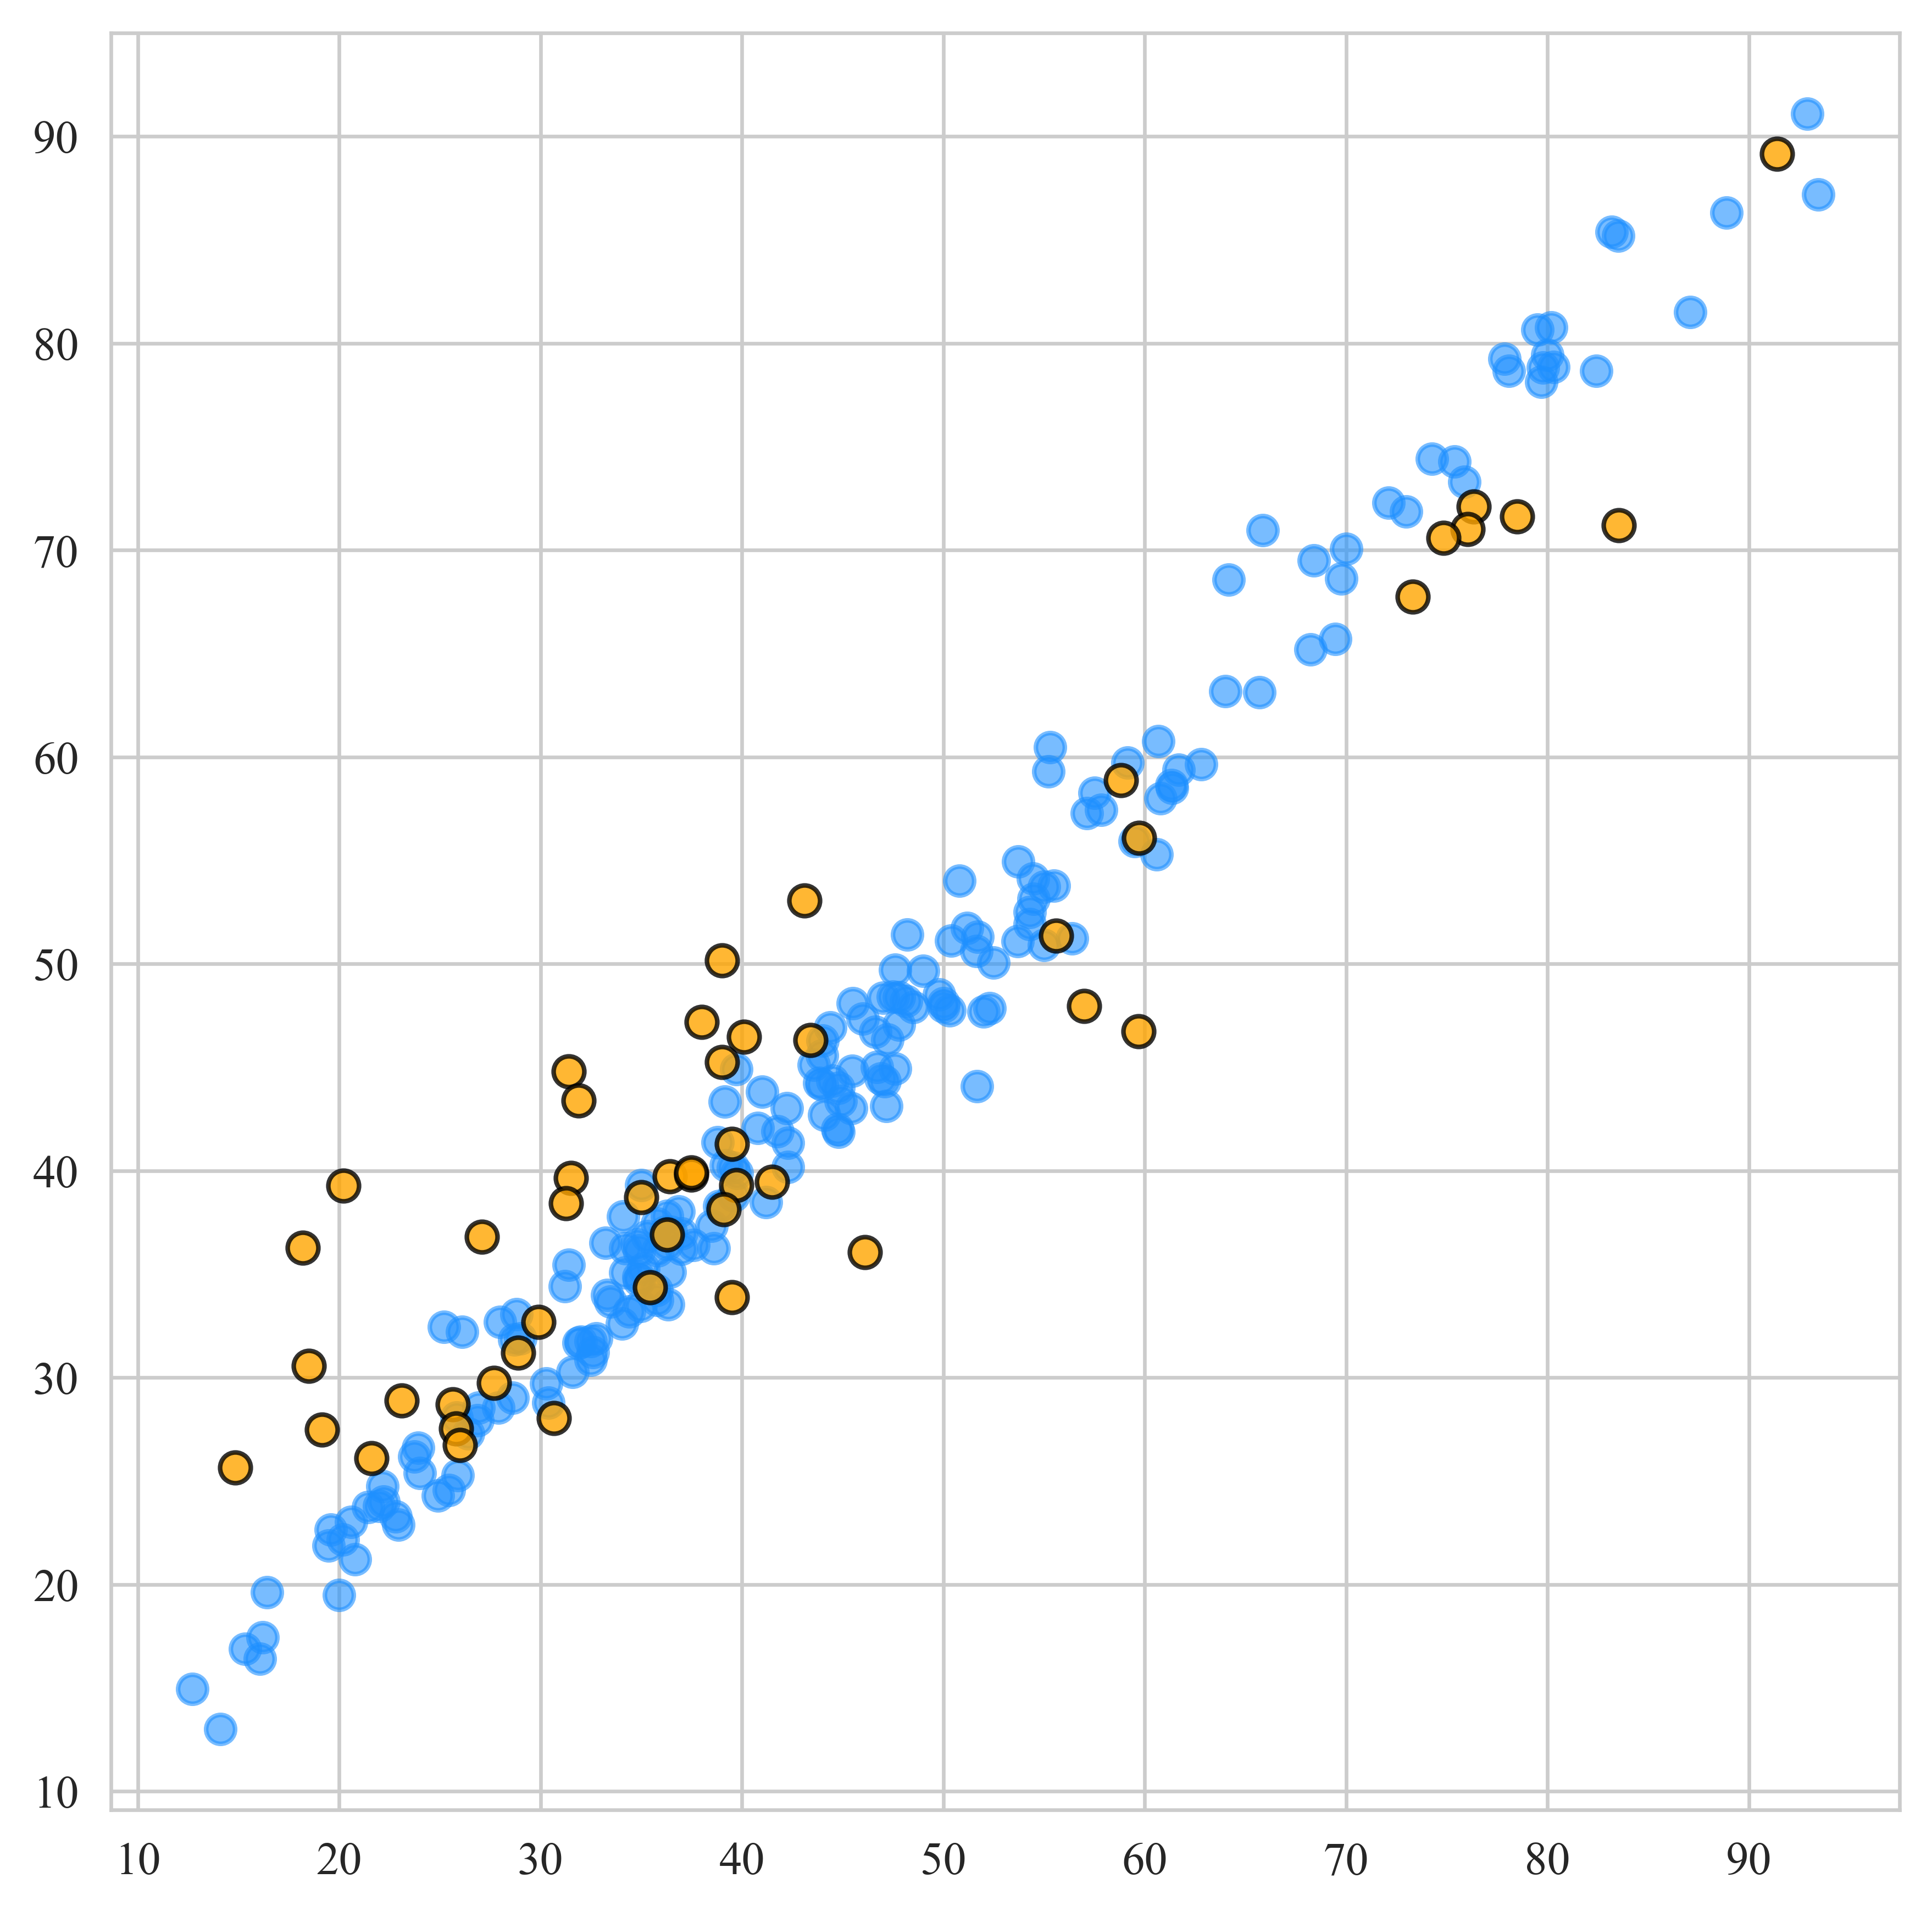

In [30]:
draw_scatter(
    y_train, train_pred,
    y_test, a['mean_pred'],   # ⭐ 注意这里
    title="Model Performance",
    test_lower=a['lower'],
    test_upper=a['upper'],
    mode='ci'   # 或 'errorbar'
)